In [1]:
### %matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust

import seaborn as sns
#import matplotlib.pylab as plt # NOT IN USE NOW, NOT RECOMMENDED TO USE. SHOULD USE PYPLOT INSTEAD
import matplotlib.pyplot as plt

import warnings # To suppress some warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
#Define the patah for the datasets
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

In [3]:
# Define the file names
# Not used here
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'
KC_TAX_CSV = DATA / 'kc_tax.csv.gz'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRPORT_DELAYS_CSV = DATA / 'dfw_airline.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
STATE_CSV = DATA / 'state.csv'

### Estimates of Location
#### Example: Location Estimates of Population and Murder Rates

In [4]:
# Load the state data
state = pd.read_csv('state.csv')
state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [5]:
# Calculate the mean of the population column
state['Population'].mean()

6162876.3

In [6]:
# this drop 10% of records from each end and calculate the mean
# this is a method to remove outliers from the mean calculation
trim_mean(state["Population"],0.1)

4783697.125

In [7]:
# Calculate the median of the population
state['Population'].median()

4436369.5

In [8]:
# caulcate the weighted mean
np.average(state['Murder.Rate'], weights=state['Population'])

4.445833981123393

### Estimates of Variability

In [9]:
# Calculate the standard deviation of the population
state['Population'].std()

6848235.347401142

In [10]:
# Calculate the IQR value - Difference of the 75% and 25% quartiles
state['Population'].quantile(0.75)-state['Population'].quantile(0.25)

4847308.0

In [11]:
# Calculate the median absolute deviation for the population
# This is less sensitive to outliers than the standard deviation (std)
robust.scale.mad(state['Population'])

3849876.1459979336

### Percentiles and Boxplots

In [12]:
# Calculate the percentile values for the following quantile list
state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64

In [13]:
# Calculate the percentile values for the following quantile list
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state['Murder.Rate'].quantile(percentages))
df.index = [f' {p * 100}%' for p in percentages]
df.T

,5.0%,25.0%,50.0%,75.0%,95.0%
Murder.Rate,1.6,2.425,4.0,5.55,6.51


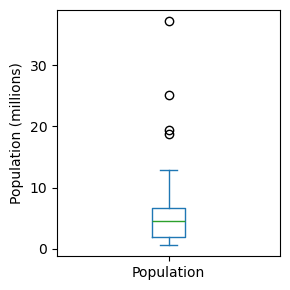

In [14]:
# Create a boxplot of the population
plt.figure(figsize=(3,3))
ax =(state['Population']/1_000_000).plot.box()
ax.set_ylabel('Population (millions)')
plt.tight_layout()
plt.show()

### Frequency Table and Histograms

In [15]:
# Split the population data into 10 bins and get a ranage and count of each bin
binnedPopulation = pd.cut(state['Population'],10)
binnedPopulation.value_counts()

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64

In [16]:
# Name the binnedPopulation column 'binnedPopulation' 
binnedPopulation.name = 'binnedPopulation'

# Concatenate the state and binnedPopulation data
df = pd.concat([state, binnedPopulation], axis=1)

# Sort the values in the dataframe by population
df = df.sort_values(by='Population')

# Group the data by the 10 bins
# In each bin append the bin range, count of rows in the bin, and the states
groups = []
for group, subset in df.groupby(by='binnedPopulation'):
    groups.append({
        'BinRange':group,
        'Count': len(subset),
        'States': ','.join(subset.Abbreviation)
    })
print(pd.DataFrame(groups))

                   BinRange  Count  \
0    (526935.67, 4232659.0]     24   
1    (4232659.0, 7901692.0]     14   
2   (7901692.0, 11570725.0]      6   
3  (11570725.0, 15239758.0]      2   
4  (15239758.0, 18908791.0]      1   
5  (18908791.0, 22577824.0]      1   
6  (22577824.0, 26246857.0]      1   
7  (26246857.0, 29915890.0]      0   
8  (29915890.0, 33584923.0]      0   
9  (33584923.0, 37253956.0]      1   

                                              States  
0  WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N...  
1          KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA  
2                                  VA,NJ,NC,GA,MI,OH  
3                                              PA,IL  
4                                                 FL  
5                                                 NY  
6                                                 TX  
7                                                     
8                                                     
9                              

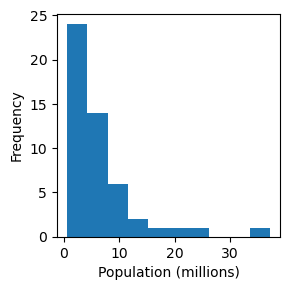

In [17]:
# Create a histogram of the population 
ax = (state["Population"]/1_000_000).plot.hist(figsize=(3,3))
ax.set_xlabel("Population (millions)")
plt.tight_layout()
plt.show()

### Density Estimates

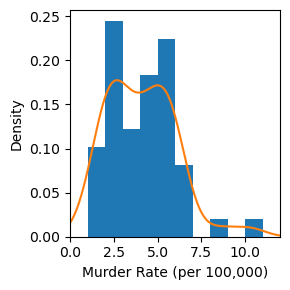

In [18]:
# Create a histogram of the murder rate and include the density curve
plt.figure(figsize=(3,3))
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
state["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')
plt.tight_layout()
plt.show()

### Exploring Binary and Categorical Data

In [19]:
# Load the airline data and display the first 5 rows
dfw = pd.read_csv('dfw_airline.csv')
dfw.head()

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


In [20]:
# Calculate the percentage of delays by cause columns
print(100 * dfw / dfw.values.sum())

     Carrier        ATC   Weather  Security    Inbound
0  23.022989  30.400781  4.025214  0.122937  42.428079


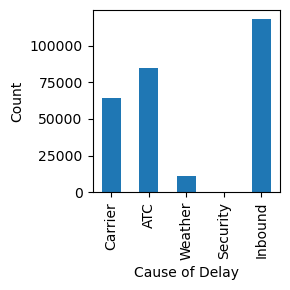

In [21]:
# Create a bar plot of the airport delays
ax = dfw.transpose().plot.bar(figsize=(3,3), legend=False)
ax.set_xlabel("Cause of Delay")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Correlation

In [22]:
# Open the sp500 data and display the first 45 rows
sp500_sym = pd.read_csv('sp500_sectors.csv')
sp500_sym.head()

,sector,sector_label,sub_sector,symbol
0,information_technology,Technology,data_processing_&_outsourced_services,ADS
1,information_technology,Technology,systems_software,CA
2,information_technology,Technology,systems_software,MSFT
3,information_technology,Technology,systems_software,RHT
4,information_technology,Technology,it_consulting_&_services,CTSH


In [23]:
sp500_px = pd.read_csv('sp500_data.csv.gz', index_col=0)
sp500_px.head()

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
1993-01-29,0.0,0.060124,-0.022100,0.0,0.0,0.018897,0.007368,0.092165,0.259140,-0.007105,...,0.0,0.0,0.34716,0.0,0.04167,0.00000,0.015564,1.75,0.1250,0.0
1993-02-01,0.0,-0.180389,0.027621,0.0,0.0,0.018889,0.018425,0.115207,-0.100775,0.063893,...,0.0,0.0,-0.23144,0.0,0.00000,-0.01041,0.007782,1.25,0.1250,0.0
1993-02-02,0.0,-0.120257,0.035900,0.0,0.0,-0.075573,0.029482,-0.023041,0.028796,-0.014192,...,0.0,0.0,-0.11572,0.0,0.00000,0.00000,-0.007792,-0.25,0.0000,0.0
1993-02-03,0.0,0.060124,-0.024857,0.0,0.0,-0.151128,0.003689,-0.253454,-0.043190,-0.007105,...,0.0,0.0,-0.08679,0.0,0.04167,-0.04167,-0.038919,-0.50,0.0625,0.0
1993-02-04,0.0,-0.360770,-0.060757,0.0,0.0,0.113350,-0.022114,0.069862,0.000000,-0.007096,...,0.0,0.0,0.14465,0.0,-0.04166,-0.03126,-0.046711,0.00,0.0625,0.0


In [24]:
# Determine telecommunications symbols
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']

# Filter data for dates July 2012 through June 2015
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
telecom.corr()
print(telecom)

                   T       CTL       FTR        VZ      LVLT
2012-07-02  0.422496  0.140847  0.070879  0.554180 -0.519998
2012-07-03 -0.177448  0.066280  0.070879 -0.025976 -0.049999
2012-07-05 -0.160548 -0.132563  0.055128 -0.051956 -0.180000
2012-07-06  0.342205  0.132563  0.007875  0.140106 -0.359999
2012-07-09  0.136883  0.124279 -0.023626  0.253943  0.180000
...              ...       ...       ...       ...       ...
2015-06-25  0.049342 -1.600000 -0.040000 -0.187790 -0.330002
2015-06-26 -0.256586  0.039999 -0.070000  0.029650 -0.739998
2015-06-29 -0.098685 -0.559999 -0.060000 -0.504063 -1.360000
2015-06-30 -0.503298 -0.420000 -0.070000 -0.523829  0.199997
2015-07-01 -0.019737  0.080000 -0.050000  0.355811  0.139999

[754 rows x 5 columns]


In [25]:
# Display the records by symbol for etf after July 1
etfs = sp500_px.loc[sp500_px.index > '2012-07-01', 
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -0.429213   
2012-07-09 -0.190939 -0.234892 -0.201098 -0.035751 -0.168687  0.000000   

                 XLV       XLP       XLF       XLK  
2012-07-02 -0.0

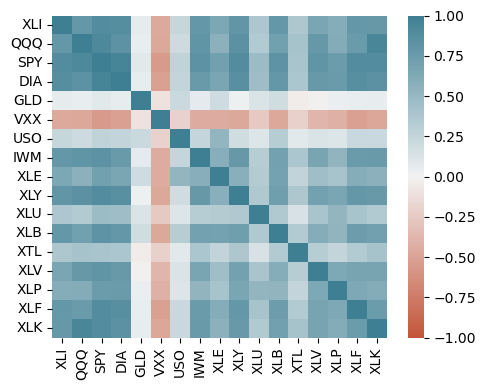

In [26]:
# Create a heamtap of the etf filtered data
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                   sp500_sym[sp500_sym['sector']=='etf']['symbol']]

plt.figure(figsize=(5,4))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
           cmap=sns.diverging_palette(20,220, as_cmap=True))
plt.tight_layout()
plt.show()

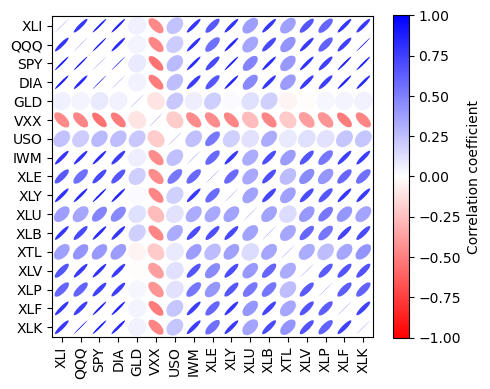

In [27]:
# Create a ellipse heatmap
# If the ellipse is pointed to the top right, they are positively correlated
# If the ellipse is pointed to the top left, they are negatively correlated
# Thinner and darker ellipses coorespond to stonger crrelations

from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize

def plot_corr_ellipses(data, figsize=None, **kwargs):

    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'aspect':'equal'})
    ax.set_xlim(-0.5, M.shape[1] - 0.5)
    ax.set_ylim(-0.5, M.shape[0] - 0.5)
    ax.invert_yaxis()

    # xy locations of each ellipse center
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T

    # set the relative sizes of the major/minor axes according to the strength of
    # the positive/negative correlation
    w = np.ones_like(M).ravel() + 0.01
    h = 1 - np.abs(M).ravel() - 0.01
    a = 45 * np.sign(M).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           norm=Normalize(vmin=-1, vmax=1),
                           transOffset=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)

    # if data is a DataFrame, use the row/column names as tick labels
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)

    return ec, ax

m, ax = plot_corr_ellipses(etfs.corr(), figsize=(5, 4), cmap='bwr_r')
fig = ax.figure
cb = fig.colorbar(m, ax=ax)
cb.set_label('Correlation coefficient')

plt.tight_layout()
plt.show()

### Scatterplots

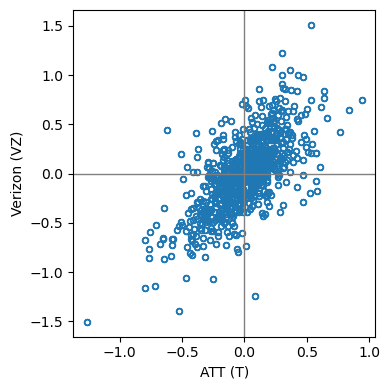

In [28]:
# Create a scatterplot of Verzion vs ATT data
ax = telecom.plot.scatter(x="T", y="VZ", figsize=(4,4), marker = '$\u25EF$')
ax.set_xlabel("ATT (T)")
ax.set_ylabel("Verizon (VZ)")

# Add horizontal and vertical lines on the 0,0 axis point
ax.axhline(0, color="grey", lw=1)
ax.axvline(0, color="grey", lw=1)
plt.tight_layout()
plt.show()

# Exploring Two or More Variables

In [29]:
# Load the tax data and display the first 5 rows
kc_tax = pd.read_csv('kc_tax.csv.gz')
kc_tax.head()

,TaxAssessedValue,SqFtTotLiving,ZipCode
0,NaN,1730,98117.0
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0


In [30]:
# Filter the tax records 
kc_tax0= kc_tax.loc[(kc_tax["TaxAssessedValue"] < 750000) &
                    (kc_tax["SqFtTotLiving"] > 100) &
                    (kc_tax["SqFtTotLiving"] < 3500), :
                   ]
kc_tax0.shape

(432693, 3)

### Hexagonal Binning and Contours

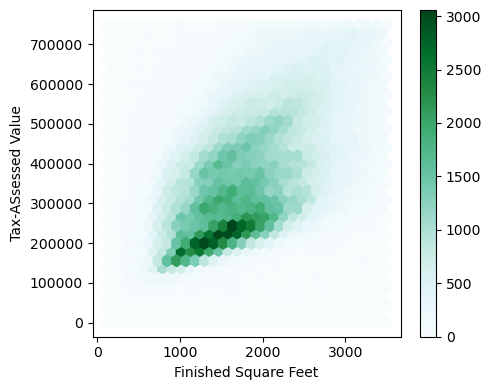

In [31]:
# Create a hexagonal binning plot
# Use this when you have 100k+ records instead of scatterplot
ax = kc_tax0.plot.hexbin(x="SqFtTotLiving", y="TaxAssessedValue",
                         gridsize=30, sharex=False, figsize=(5,4))
ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax-ASsessed Value")
plt.tight_layout()
plt.show()

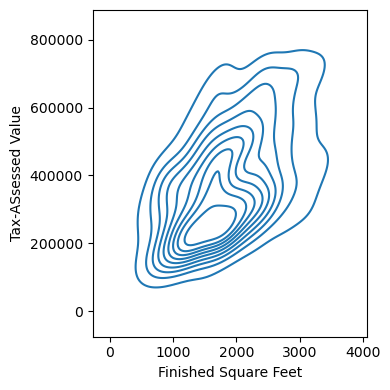

In [32]:
# Create a kdeplot of the data
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.kdeplot(data=kc_tax0.sample(1000), x="SqFtTotLiving", y="TaxAssessedValue", ax=ax)
ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax-ASsessed Value")
plt.tight_layout()
plt.show()

## Two Categorical Variables

In [33]:
# Laod the loan data
lc_loans = pd.read_csv('lc_loans.csv')
lc_loans.head()

,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B


In [34]:
# Pivot the loan dataset rows are by 'grade', columns are by 'status'
crosstab = lc_loans.pivot_table(
    index="grade",
    columns = "status",
    aggfunc=lambda x: len(x), margins=True)

print(crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961


In [35]:
# Take the crosstab dataframe above and calculate the percentages each status relates to a grade row
df = crosstab.loc['A':'G',:].copy()
df.loc[:,"Charged Off":"Late"] = df.loc[:,"Charged Off":"Late"].div(df['All'], axis=0)
df["All"]=df["All"]/sum(df["All"])
perc_crosstab = df
print(perc_crosstab)

status  Charged Off   Current  Fully Paid      Late       All
grade                                                        
A          0.021548  0.690454    0.281528  0.006470  0.160746
B          0.040054  0.709013    0.235401  0.015532  0.293529
C          0.049828  0.735702    0.191495  0.022974  0.268039
D          0.067410  0.717328    0.184189  0.031073  0.164708
E          0.081657  0.707936    0.170929  0.039478  0.077177
F          0.118258  0.654371    0.180409  0.046962  0.028614
G          0.126196  0.614008    0.198396  0.061401  0.007187


## Categorical and Numeric Data

In [36]:
# OPen the airline statistics data
airline_stats = pd.read_csv('airline_Stats.csv')
airline_stats.head()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


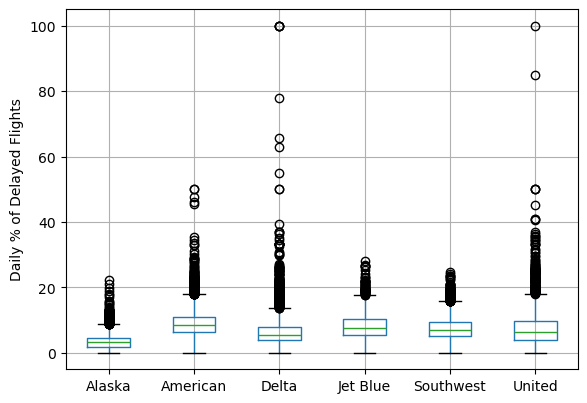

In [37]:
# Create a boxplot by airline and pct_carrier_delay
ax = airline_stats.boxplot(by="airline", column="pct_carrier_delay")
ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")
plt.title('')
plt.suptitle('')
plt.show()

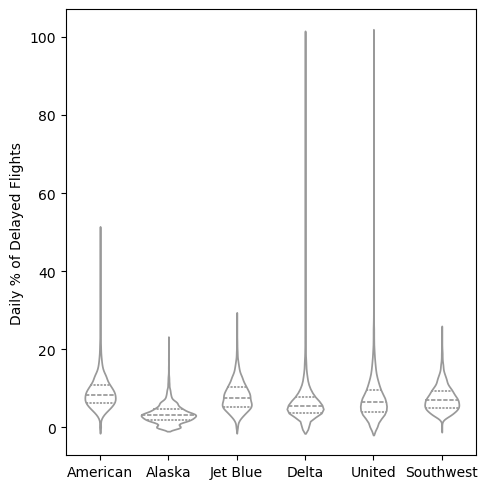

In [38]:
# Create a violin plot by airline and pct_carrier_delay
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               ax=ax, inner='quartile', color='white')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

plt.tight_layout()
plt.show()

### Visualizing Multiple Variables

In [39]:
# Filter the tax data by 4 zipcodes
# Diplay the first 5 rows
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes),:]
kc_tax_zip[:5]

,TaxAssessedValue,SqFtTotLiving,ZipCode
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0
10,202000.0,830,98108.0
11,210000.0,1130,98108.0
12,193000.0,1560,98108.0


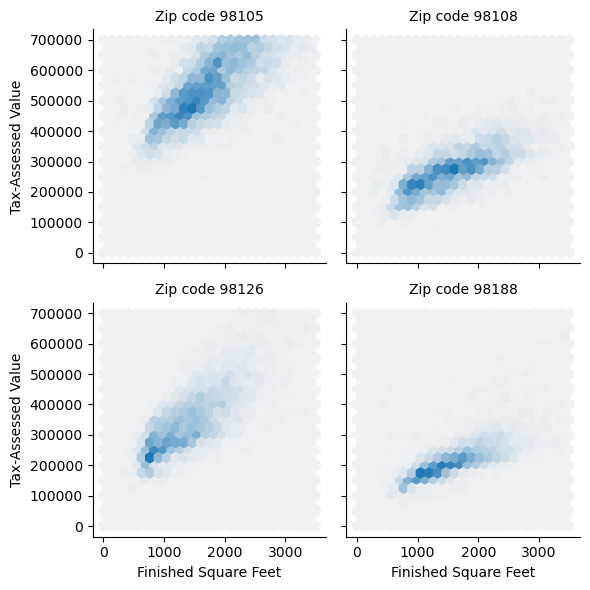

In [40]:
# Create a hexbin plot for every zipcode in the filter
def hexbin(x,y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x,y,gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue',
    extent=[0,3500,0,700000])
g.set_axis_labels('Finished Square Feet','Tax-Assessed Value')
g.set_titles('Zip code {col_name:.0f}')
plt.show()